<img src="https://github.com/lid-ufpa/genial/blob/main/assets/genial-logo-banner-dark.png?raw=true" style="width:100%; height:auto;">

# **Aula 3 - Otimização por Colônia de Formigas (ACO)**

Seja bem vindo(a) ao curso **Genetic and Evolutionary Nature-Inspired ALgorithms (GENIAL)**.

Nesta terceira aula, vamos explorar a fundo o algoritmo de Otimização por Colônia de Formigas, conceituar os seus componentes básicos, descrever o seu processo iterativo e codificar um exemplo prático de ACO para resolver um problema real.

In [1]:
import random

import matplotlib.pyplot as plt
import pandas as pd
from aco_utils.animar_aco import animar_aco
from aco_utils.plotar_cidades import plotar_cidades
from aco_utils.tsp_aco import TSPACO
from aco_utils.visualizar_grade import visualizar_grade
from IPython.display import HTML

In [2]:
random.seed(42)

## 3.1 Introdução

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/ants.jpeg?raw=true" style="width:100%; height:auto;">

**Otimização por Colônia de Formigas (ACO)** é uma classe de algoritmos de busca e otimização inspirada no comportamento coletivo das formigas na natureza. Proposto por **Marco Dorigo** na década de 1990, o método imita os princípios de **cooperação** e **auto-organização** observados em colônias de formigas para encontrar soluções aproximadas para problemas complexos, especialmente aqueles de **otimização combinatória**.

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/ants.gif?raw=true" style="width:600px; height:auto;">

Baseia-se na observação do comportamento social das formigas, de onde é importado o seguinte vocabulário:

- Formiga 🐜
- Caminho 🗺️
- Feromônio 💮
- Evaporação 💨
- Deposição 

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/aco.png?raw=true" width="400">
</p>

A ideia central é simular o processo pelo qual formigas reais encontram o caminho mais curto entre o ninho e uma fonte de alimento. Cada formiga **constrói soluções** movendo-se pelo espaço do problema e **depositando feromônios** nos caminhos percorridos. As trilhas com maior concentração de feromônios tornam-se mais atrativas, aumentando a probabilidade de serem escolhidas por outras formigas em iterações futuras.

Com o tempo, esse processo coletivo leva a colônia a **convergir para caminhos mais curtos ou soluções mais eficientes**. A evaporação dos feromônios impede que soluções antigas dominem a busca, mantendo o equilíbrio entre **exploração** de novas rotas e **exploração** de soluções promissoras já conhecidas.

Os algoritmos ACO são particularmente úteis em problemas de:

- Otimização combinatória (e.g., Problema do Caixeiro Viajante, roteamento de veículos, escalonamento de tarefas).  
- Busca de caminhos em grafos complexos.  
- Planejamento e roteamento em redes.  

ACO difere de métodos tradicionais (e também de AGs) em quatro pontos principais:

1. ACO trabalha com uma **população de agentes cooperativos** (formigas), que interagem indiretamente por meio de feromônios.  
2. ACO utiliza **memória distribuída** — o ambiente guarda a informação sobre boas soluções por meio das trilhas de feromônio.  
3. ACO combina **regras probabilísticas de decisão** com **mecanismos de reforço** baseados no desempenho das soluções.  
4. ACO realiza uma **busca construtiva**, em que cada formiga monta gradualmente uma solução a partir dos elementos do problema. 

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/aco_difference.png" width="1280">
</p>

## 3.2 Estrutura do ACO

Para compreender a estrutura básica de um algoritmo de Otimização por Colônia de Formigas (ACO), vamos analisar um exemplo simples: o **problema do caminho mínimo em uma grade 2D**. Nesse problema, uma formiga precisa sair do canto superior esquerdo da grade e chegar ao canto inferior direito, movendo-se apenas **para a direita** ou **para baixo**. Cada célula da grade possui um **custo de travessia**, e o objetivo é encontrar o **caminho de menor custo total**.

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/fluxograma_aco.png" width="1280">
</p>

### 3.2.1 Representação do Problema

O ACO modela esse problema como um **grafo**, em que:

- Os **nós** representam as células da grade.
- As **arestas** representam os movimentos possíveis entre células adjacentes (direita ou abaixo).
- Cada **aresta** possui um valor de **feromônio**, que indica sua atratividade.

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/demonstracao.png" width="1280">
</p>


In [3]:
n = 5
custos = [[random.randint(1, 9) for _ in range(n)] for _ in range(n)]

pd.DataFrame(custos)

,0,1,2,3,4
0,2,1,5,4,4
1,3,2,9,2,7
2,1,1,2,4,4
3,9,1,9,4,9
4,7,4,8,5,1


Para facilitar a visualização, agora não usaremos a visualização de um grafo, mas sim a de uma grade.

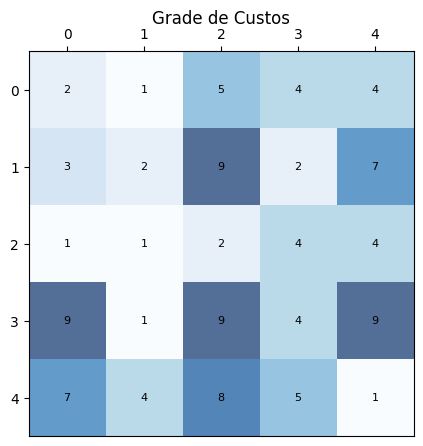

In [4]:
visualizar_grade(custos, titulo="Grade de Custos")

### 3.2.1 Formigas

As **formigas** são agentes independentes e cooperativos que constroem soluções. No estágio inicial, as formigas se movem **aleatoriamente**, apenas garantindo que o caminho seja válido. Mais adiante, elas passarão a decidir com base no **nível de feromônio** e na **heurística local**. Cada formiga constrói um caminho completo, uma sequência de nós, que representa uma possível **solução** ao problema.

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/artificial-ants.gif?raw=true" style="width:1000px; height:auto;">

In [5]:
n_formigas = 3
formigas = []

for _ in range(n_formigas):
    i, j = 0, 0
    caminho = [(i, j)]
    while (i, j) != (n - 1, n - 1):
        movimentos = []
        if i < n - 1:
            movimentos.append((i + 1, j))
        if j < n - 1:
            movimentos.append((i, j + 1))
        i, j = random.choice(movimentos)
        caminho.append((i, j))
    formigas.append(caminho)

for idx, caminho in enumerate(formigas):
    print(f"Formiga {idx+1}: {caminho}")

Formiga 1: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 4), (4, 4)]
Formiga 2: [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
Formiga 3: [(0, 0), (1, 0), (1, 1), (2, 1), (2, 2), (2, 3), (3, 3), (4, 3), (4, 4)]


Ao percorrer a **grade 2D**, cada formiga começa no **canto superior esquerdo** (origem) e, a cada passo, escolhe o próximo movimento possível (para a **direita** ou **para baixo**), até alcançar o **canto inferior direito** (destino). 

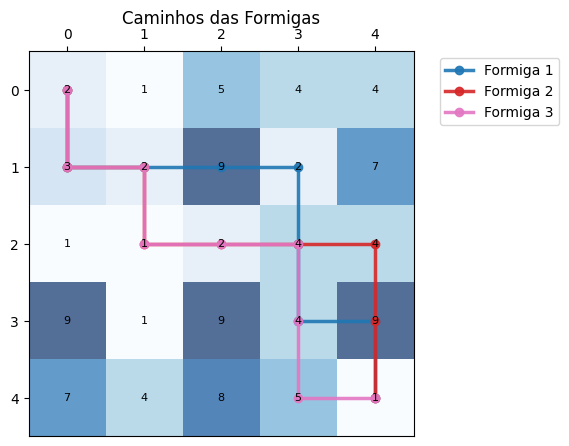

In [6]:
visualizar_grade(custos, formigas=formigas, titulo="Caminhos das Formigas")

### 3.2.2 Feromônios

O **feromônio** é o mecanismo de comunicação indireta entre as formigas. Cada aresta da grade possui um valor de feromônio, que é atualizado a cada iteração do algoritmo, seguindo duas dinâmicas principais:

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/feromonios.png" width="1280">
</p>

1. **Evaporação:** reduz o feromônio em todas as arestas, evitando convergência prematura e mantendo diversidade na busca.  
2. **Deposição:** adiciona feromônio nas arestas pertencentes às melhores soluções, reforçando caminhos promissores.

In [7]:
feromonios = [[1.0 / n for _ in range(n)] for _ in range(n)]
taxa_evaporacao = 0.2
delta_feromonio = 0.1

print("Feromônios antes da evaporação:")
pd.DataFrame(feromonios)

Feromônios antes da evaporação:


,0,1,2,3,4
0,0.2,0.2,0.2,0.2,0.2
1,0.2,0.2,0.2,0.2,0.2
2,0.2,0.2,0.2,0.2,0.2
3,0.2,0.2,0.2,0.2,0.2
4,0.2,0.2,0.2,0.2,0.2


In [8]:
for i in range(n):
    for j in range(n):
        feromonios[i][j] *= (1 - taxa_evaporacao)

print("Feromônios após evaporação:")
pd.DataFrame(feromonios)

Feromônios após evaporação:


,0,1,2,3,4
0,0.16,0.16,0.16,0.16,0.16
1,0.16,0.16,0.16,0.16,0.16
2,0.16,0.16,0.16,0.16,0.16
3,0.16,0.16,0.16,0.16,0.16
4,0.16,0.16,0.16,0.16,0.16


In [9]:
for caminho in formigas:
    for (i, j) in caminho:
        feromonios[i][j] += delta_feromonio

print("Feromônios após deposição:")
pd.DataFrame(feromonios)

Feromônios após deposição:


,0,1,2,3,4
0,0.46,0.16,0.16,0.16,0.16
1,0.46,0.46,0.26,0.26,0.16
2,0.16,0.36,0.36,0.46,0.26
3,0.16,0.16,0.16,0.36,0.36
4,0.16,0.16,0.16,0.26,0.46


### 3.2.5 Função Objetivo

A **função objetivo** avalia a qualidade do caminho construído por cada formiga. Nesse caso, a qualidade de um caminho é dado pela soma dos custos de cada aresta visitada. O objetivo é **minimizar o custo total** do caminho da formiga.

In [10]:
custos_formigas = []

for caminho in formigas:
    custo_total = sum(custos[i][j] for i, j in caminho)
    custos_formigas.append(custo_total)

melhor_custo = min(custos_formigas)
melhor_formiga = custos_formigas.index(melhor_custo)

df = pd.DataFrame({
    "Formiga": [f"Formiga {i+1}" for i in range(len(custos_formigas))],
    "Custo Total": custos_formigas,
    "Melhor?": ["Sim" if i == melhor_formiga else "Não" for i in range(len(custos_formigas))],
})

df

,Formiga,Custo Total,Melhor?
0,Formiga 1,36,Não
1,Formiga 2,28,Não
2,Formiga 3,24,Sim


## 3.3 Etapas do ACO

Imagem do fluxograma

### 3.3.1 Inicialização

Nessa etapa, os parâmetros do algoritmo e as variáveis principais são definidos. Isso inclui:

- A **matriz de custos** da grade (custo de cada célula ou movimento).  
- A **matriz de feromônios**, representando a trilha deixada pelas formigas.  
- Parâmetros de controle: $\alpha$, $\beta$, número de formigas, número de iterações e taxa de evaporação.  

O feromônio inicial é geralmente pequeno e uniforme, indicando conhecimento neutro antes do aprendizado coletivo.

In [11]:
n = 10

custos = [[random.randint(1, 20) for _ in range(n)] for _ in range(n)]
feromonios = [[1.0 / n for _ in range(n)] for _ in range(n)]

alfa = 1.0
beta = 2.0
n_formigas = 5
n_iteracoes = 10
taxa_evaporacao = 0.3

melhor_solucao = []
melhor_custo = float("inf")

print("Matriz de custos:")
display(pd.DataFrame(custos))

print("\nMatriz de feromônios inicial:")
display(pd.DataFrame(feromonios))

Matriz de custos:


,0,1,2,3,4,5,6,7,8,9
0,8,10,3,8,4,13,9,15,12,6
1,12,12,7,9,3,20,6,18,8,6
2,15,13,9,18,8,11,2,8,2,11
3,13,9,3,7,19,11,7,16,13,15
4,5,9,5,8,18,18,9,19,14,19
5,13,12,8,5,17,16,3,2,4,5
6,6,14,20,3,13,13,20,15,17,9
7,18,1,4,18,9,11,4,10,14,6
8,15,1,9,17,6,17,4,10,17,20
9,7,5,12,6,18,17,1,20,11,16



Matriz de feromônios inicial:


,0,1,2,3,4,5,6,7,8,9
0,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
4,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
5,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
6,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
7,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
8,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
9,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1


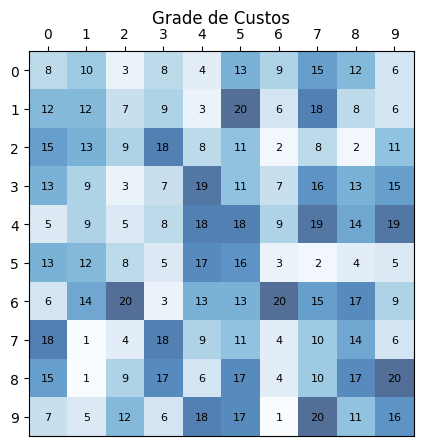

In [12]:
visualizar_grade(custos, titulo="Grade de Custos")

### 3.3.2 Construção das Soluções

Na etapa de **construção de soluções**, cada formiga inicia em um ponto da grade e percorre um caminho até o destino final. A escolha de cada próximo movimento é feita de forma **probabilística**, considerando simultaneamente o **feromônio acumulado** e a **informação heurística local**, que neste caso é o inverso do custo da célula vizinha. A probabilidade de mover-se da célula $i$ para a célula $j$ é calculada como:

$$
P_{i, j} = \frac{\tau_{i,j}^\alpha \, \eta_{i,j}^\beta}{\sum_{k \in C_i} \tau_{i,k}^\alpha \, \eta_{i,k}^\beta}
$$

onde $\tau_{i,j}$ representa a quantidade de feromônio na célula $(i,j)$, $\eta_{i,j} = 1 / \text{custo}_{i,j}$ é o valor heurístico da célula, $\alpha$ é o peso do feromônio, $\beta$ é o peso da heurística, e $C_i$ é o conjunto de células possíveis a partir de $i$.

Ao final desta etapa, cada formiga terá gerado uma **solução completa**, ou seja, um caminho do início ao fim da grade. O conjunto de todas as formigas resulta em um **conjunto de soluções candidatas**, pronto para ser avaliado na etapa seguinte.


In [13]:
def calcular_probabilidades(movimentos):
    numeradores = []
    for (x, y) in movimentos:
        tau = feromonios[x][y] ** alfa
        eta = (1.0 / custos[x][y]) ** beta if custos[x][y] > 0 else 0
        numeradores.append(tau * eta)
    soma = sum(numeradores)
    if soma == 0:
        return [1.0 / len(movimentos)] * len(movimentos)
    return [num / soma for num in numeradores]

def construir_caminho():
    i, j = 0, 0
    caminho = [(i, j)]
    while (i, j) != (n - 1, n - 1):
        movimentos = []
        if i < n - 1:
            movimentos.append((i + 1, j))
        if j < n - 1:
            movimentos.append((i, j + 1))

        probabilidades = calcular_probabilidades(movimentos)
        i, j = random.choices(movimentos, weights=probabilidades, k=1)[0]
        caminho.append((i, j))

    return caminho

def construir_solucoes():
    return [construir_caminho() for _ in range(n_formigas)]

formigas = construir_solucoes()
for idx, caminho in enumerate(formigas):
    print(f"Formiga {idx+1}: {caminho}")

Formiga 1: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (5, 7), (5, 8), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]
Formiga 2: [(0, 0), (0, 1), (0, 2), (1, 2), (1, 3), (1, 4), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (5, 7), (5, 8), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]
Formiga 3: [(0, 0), (1, 0), (1, 1), (1, 2), (2, 2), (3, 2), (3, 3), (4, 3), (5, 3), (6, 3), (6, 4), (7, 4), (7, 5), (7, 6), (8, 6), (9, 6), (9, 7), (9, 8), (9, 9)]
Formiga 4: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (1, 4), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (5, 7), (5, 8), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]
Formiga 5: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (5, 7), (5, 8), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


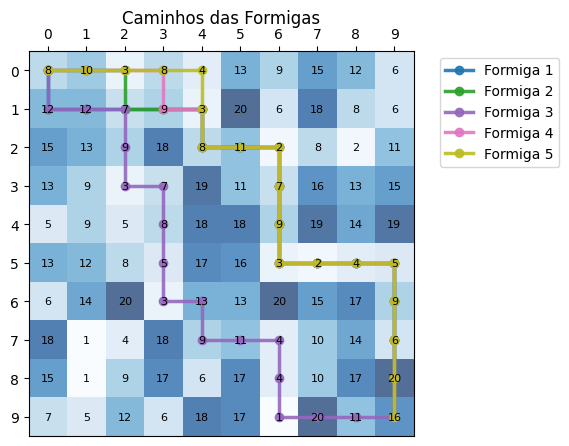

In [14]:
visualizar_grade(custos, formigas=formigas, titulo="Caminhos das Formigas")

### 3.3.3 Avaliação das Soluções

A **função objetivo** é responsável por avaliar as soluções. No caso da grade 2D, a qualidade é medida pelo **custo total do caminho percorrido**, ou seja, a soma dos valores das arestas visitadas. O objetivo do ACO é **minimizar essa função**, encontrando o caminho mais curto que passa por todas as células e retorna ao ponto inicial.

In [15]:
def calcular_custos(formigas):
    custos_formigas = []
    for caminho in formigas:
        custo_total = sum(custos[i][j] for i, j in caminho)
        custos_formigas.append(custo_total)
    return custos_formigas

custos_formigas = calcular_custos(formigas)

melhor_custo = min(custos_formigas)
melhor_formiga = custos_formigas.index(melhor_custo)

df = pd.DataFrame({
    "Formiga": [f"Formiga {i+1}" for i in range(len(custos_formigas))],
    "Custo Total": custos_formigas,
    "Melhor?": ["Sim" if i == melhor_formiga else "Não" for i in range(len(custos_formigas))]
})

df

,Formiga,Custo Total,Melhor?
0,Formiga 1,153,Não
1,Formiga 2,142,Não
2,Formiga 3,163,Não
3,Formiga 4,143,Não
4,Formiga 5,138,Sim


### 3.3.4 Atualização dos Feromônios

Após todas as formigas completarem suas rotas, o feromônio é atualizado em duas etapas:

1. **Evaporação:** reduz o feromônio existente em todas as arestas, evitando que soluções antigas dominem a busca.  
2. **Deposição:** aumenta o feromônio nas arestas usadas por boas soluções, reforçando rotas promissoras.

O modelo de atualização é dado por:

$$
\tau_{ij} \leftarrow (1 - \rho)\tau_{ij} + \sum_{k=1}^{m} \frac{1}{L_k}
$$

onde $\rho$ é a **taxa de evaporação**, $L_k$ é o **custo da solução** da formiga $k$, e $\tau_{ij}$ representa a **quantidade de feromônio** na aresta $(i, j)$.


In [16]:
historico_feromonios = []

def atualizar_feromonios(formigas, custos_formigas):
    global feromonios, melhor_custo, melhor_solucao

    for i in range(n):
        for j in range(n):
            feromonios[i][j] *= (1 - taxa_evaporacao)

    for caminho, custo in zip(formigas, custos_formigas, strict=True):
        deposito = 1.0 / custo
        for i, j in caminho:
            feromonios[i][j] += deposito
        if custo <= melhor_custo:
            melhor_custo = custo
            melhor_solucao = caminho

    historico_feromonios.append([row[:] for row in feromonios])

print("Feromônios antes da atualização:")
display(pd.DataFrame(feromonios))

atualizar_feromonios(formigas, custos_formigas)

print("\nFeromônios após a atualização:")
display(pd.DataFrame(feromonios))

Feromônios antes da atualização:


,0,1,2,3,4,5,6,7,8,9
0,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
2,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
3,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
4,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
5,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
6,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
7,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
8,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
9,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1



Feromônios após a atualização:


,0,1,2,3,4,5,6,7,8,9
0,0.103953,0.091282,0.091282,0.084239,0.077246,0.070000,0.070000,0.070000,0.070000,0.070000
1,0.082671,0.082671,0.089713,0.090571,0.097818,0.070000,0.070000,0.070000,0.070000,0.070000
2,0.070000,0.070000,0.076135,0.070000,0.097818,0.097818,0.097818,0.070000,0.070000,0.070000
3,0.070000,0.070000,0.076135,0.076135,0.070000,0.070000,0.097818,0.070000,0.070000,0.070000
4,0.070000,0.070000,0.070000,0.076135,0.070000,0.070000,0.097818,0.070000,0.070000,0.070000
5,0.070000,0.070000,0.070000,0.076135,0.070000,0.070000,0.097818,0.097818,0.097818,0.097818
6,0.070000,0.070000,0.070000,0.076135,0.076135,0.070000,0.070000,0.070000,0.070000,0.097818
7,0.070000,0.070000,0.070000,0.070000,0.076135,0.076135,0.076135,0.070000,0.070000,0.097818
8,0.070000,0.070000,0.070000,0.070000,0.070000,0.070000,0.076135,0.070000,0.070000,0.097818
9,0.070000,0.070000,0.070000,0.070000,0.070000,0.070000,0.076135,0.076135,0.076135,0.103953


### 3.3.5 Iteração e Critério de Parada

No ACO, cada iteração consiste em três passos principais: a construção de soluções por todas as formigas, a avaliação dessas soluções e a atualização global dos feromônios. O processo se repete por várias iterações, permitindo que as formigas converjam gradualmente para soluções de menor custo. O critério de parada é definido pelo número máximo de iterações.

In [17]:
log_iteracoes = []
melhor_custo_por_iteracao = []

for iteracao in range(n_iteracoes):
    solucoes = construir_solucoes()
    custos_solucoes = calcular_custos(solucoes)
    atualizar_feromonios(solucoes, custos_solucoes)
    log_iteracoes.append({"Iteração": iteracao+1, "Melhor Custo": melhor_custo})
    melhor_custo_por_iteracao.append(melhor_custo)

print(f"Melhor Solução: {melhor_solucao}")
pd.DataFrame(log_iteracoes)

Melhor Solução: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (2, 5), (2, 6), (3, 6), (4, 6), (5, 6), (5, 7), (5, 8), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


,Iteração,Melhor Custo
0,1,138
1,2,138
2,3,138
3,4,138
4,5,138
5,6,138
6,7,138
7,8,138
8,9,138
9,10,138


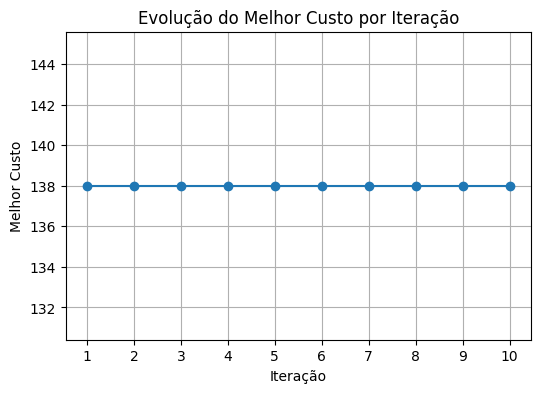

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, n_iteracoes+1), melhor_custo_por_iteracao, marker="o")
plt.xlabel("Iteração")
plt.ylabel("Melhor Custo")
plt.title("Evolução do Melhor Custo por Iteração")
plt.xticks(range(1, n_iteracoes+1))
plt.grid(visible=True)
plt.show()

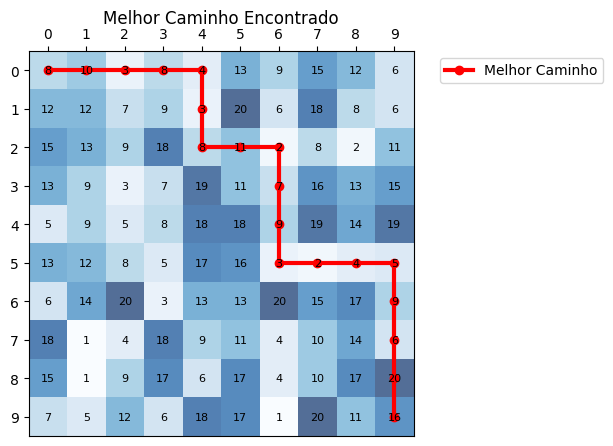

In [19]:
visualizar_grade(custos, melhor_caminho=melhor_solucao, titulo="Melhor Caminho Encontrado")

## 3.4 Definição Formal

Seja $G = (V, E)$ um grafo em que cada vértice $v \in V$ representa um estado, e cada aresta $(i,j) \in E$ representa uma transição entre estados, associada a um feromônio $\tau_{ij}$. Considere também uma heurística $\eta_{ij}$ e uma função objetivo $f : \mathcal{S} \to \mathbb{R}$, onde $\mathcal{S}$ é o conjunto de soluções possíveis, tal que $f(s)$ fornece o custo da solução $s$. 

O problema de otimização pode ser formulado como:

$$
s^* = \arg\min_{s \in \mathcal{S}} f(s),
$$

ou, de modo equivalente, em termos de maximização:

$$
s^* = \arg\min_{s \in \mathcal{S}} -f(s),
$$

onde $s^*$ é a melhor solução encontrada de acordo com a função objetivo $f$.

---

O algoritmo é iterativo. Em cada iteração $t = 1, 2, \dots, T$:  
1. Cada formiga constrói uma solução $s_k^t$ ao percorrer o grafo.  
2. Cada solução é avaliada pela função objetivo $f(s_k^t)$.  
3. Os níveis de feromônio $\tau_{ij}$ são atualizados (evaporação + depósito).  
4. A melhor solução global $s^*$ é atualizada: 
   $$
   s^* \leftarrow \arg\min_{s \in \{s^*, s_k^t\}} f(s).
   $$

Esse ciclo é repetido até que se atinja o critério de parada (número máximo de iterações, tempo limite ou ausência de melhoria).

---

A regra de transição que determina a escolha do próximo estado $j$ pela formiga $k$, estando em $i$, é:

$$
P^k_{ij} =
\begin{cases}
\dfrac{\tau_{ij}^\alpha \, \eta_{ij}^\beta}{\sum\limits_{l \in N_i^k} \tau_{il}^\alpha \, \eta_{il}^\beta}, & \text{se } j \in N_i^k, \\[10pt]
0, & \text{caso contrário},
\end{cases}
$$

onde $N_i^k$ é o conjunto de estados que a formiga $k$ ainda pode acessar a partir de $i$, 
e $\alpha, \beta > 0$ são pesos que determinam a influência do feromônio e da heurística.

---

A evaporação dos feromônios é dada por: $$ \tau_{ij} \leftarrow (1 - \rho)\,\tau_{ij}, $$ onde $\rho \in (0,1]$ é a taxa de evaporação. Já o depósito é dado por: $$ \tau_{ij} \leftarrow \tau_{ij} + \sum_{k=1}^m \Delta \tau_{ij}^k, $$ com: $$ \Delta\tau_{ij}^k = \begin{cases} \dfrac{Q}{L_k}, & \text{se a formiga $k$ usou a aresta $(i,j)$ na sua solução}, \\[10pt] 0, & \text{caso contrário}, \end{cases} $$ em que $m$ é o número total de formigas, $Q > 0$ é uma constante, e $L_k = f(s_k)$ é o custo da solução $s_k$ construída pela formiga $k$ segundo a função objetivo $f$.

## 3.5 Exemplo

### 3.5.1 Problema do Caixeiro Viajante (TSP)

O Problema do Caixeiro Viajante consiste em encontrar o menor caminho que percorra todas as cidades de um conjunto, passando apenas uma vez por cada cidade e retornando à cidade de origem. Esse problema é considerado NP-difícil, o que significa que algoritmos exatos tornam-se inviáveis quando o número de cidades cresce. Por isso, o TSP é um dos problemas clássicos onde metaheurísticas são aplicadas.

### 3.5.2 Representação do Problema

O problema do caixeiro viajante pode ser modelado como um grafo, em que:

- Os **nós** representam as cidades.  
- As **arestas** representam os caminhos possíveis entre as cidades.  
- O **custo** representa as distâncias euclidianas entre as cidades.

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/caixeiro_viajante.png" width="950">
</p>

Os custos podem ser representados por uma matriz, onde cada elemento $C_{ij}$ indica o custo de ir da cidade $i$ para a cidade $j$:

$$
C =
\begin{bmatrix}
0 & c_{12} &  \dots & c_{1n} \\
c_{21} & 0 & \dots & c_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
c_{n1} & c_{n2} & \dots & 0
\end{bmatrix}
$$

- A diagonal principal contém zeros, pois o custo de ir de uma cidade para ela mesma é nulo.  
- A matriz pode ser simétrica (distância de $i$ para $j$ é igual à de $j$ para $i$) ou assimétrica (quando há diferença, como em custos de tráfego ou logística).  

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/matriz_exemplo.png" width="950">
</p>

---

<p align="center">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/mapa1.gif" width="450">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula03/mapa2.gif" width="650">
</p>
Uma solução para o TSP é uma permutação dos vértices (cidades), que define a ordem de visitação.

Por exemplo, considere 4 cidades e a matriz de custos:

$$
C =
\begin{bmatrix}
0 & 10 & 15 & 20 \\
10 & 0 & 35 & 25 \\
15 & 35 & 0 & 30 \\
20 & 25 & 30 & 0
\end{bmatrix}
$$

Uma solução possível é a rota:

$$
[0, 2, 3, 1, 0]
$$

O custo total dessa solução é calculado somando os valores correspondentes da matriz:

$$
C_{0,2} + C_{2,3} + C_{3,1} + C_{1,0}
= 15 + 30 + 25 + 10 = 80
$$

### 3.5.3 Definição dos Parâmetros e Hiperparâmetros

In [20]:
N_CIDADES = 20
N_FORMIGAS = 20
N_ITERACOES = 15
ALFA = 1.0
BETA = 3.0
TAXA_EVAPORACAO = 0.7
VERTICE_INICIAL = 0

### 3.5.4 Criação da Instância do Problema

In [21]:
coordenadas = [(random.uniform(0, 200), random.uniform(0, 200)) for _ in range(N_CIDADES)]
distancias = [[0.0 for _ in range(N_CIDADES)] for _ in range(N_CIDADES)]

for i in range(N_CIDADES):
    for j in range(N_CIDADES):
        if i != j:
            x = (coordenadas[i][0] - coordenadas[j][0]) ** 2
            y = (coordenadas[i][1] - coordenadas[j][1]) ** 2
            distancias[i][j] = (x + y) ** (1/2)

display(pd.DataFrame(distancias))

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.000000,42.260574,104.501696,94.971705,157.215134,113.097827,118.146919,112.798804,151.401627,107.858161,124.323889,155.730259,133.120555,84.987371,8.217062,90.672021,152.834615,51.037681,115.668257,80.834679
1,42.260574,0.000000,63.708282,62.352288,156.794916,71.136049,139.559379,102.913057,166.933653,76.291158,137.509937,155.761558,123.313718,98.236008,44.256910,62.776817,179.855601,91.541605,108.871594,66.668210
2,104.501696,63.708282,0.000000,72.392304,193.932732,33.522525,196.406637,136.127364,218.470733,81.794505,188.765251,193.480154,153.169030,152.631908,107.648688,82.529593,238.987066,154.949598,144.600420,104.417760
3,94.971705,62.352288,72.392304,0.000000,122.609030,48.519062,140.171777,65.166617,154.670853,13.969131,126.003947,122.329168,80.989932,96.587862,92.240541,12.399946,184.679083,132.206144,74.153952,40.422725
4,157.215134,156.794916,193.932732,122.609030,0.000000,170.547103,81.136832,57.805429,60.708784,117.179507,53.624977,2.099099,43.067138,77.115299,149.376915,111.542151,111.672891,153.033031,49.565924,91.962113
5,113.097827,71.136049,33.522525,48.519062,170.547103,0.000000,185.366879,113.515774,202.498432,53.944303,173.421513,170.370351,128.199489,141.142901,113.868468,60.581880,229.438427,160.033184,122.593938,87.078030
6,118.146919,139.559379,196.406637,140.171777,81.136832,185.366879,0.000000,90.768577,37.747845,143.084101,27.759031,79.039738,95.984273,44.260555,110.164158,127.966000,44.558969,90.210072,83.346452,99.759314
7,112.798804,102.913057,136.127364,65.166617,57.805429,113.515774,90.768577,0.000000,94.533222,61.372895,69.015386,57.376029,20.681247,56.932122,106.000229,53.805137,133.765979,125.336417,9.350266,36.263564
8,151.401627,166.933653,218.470733,154.670853,60.708784,202.498432,37.747845,94.533222,0.000000,154.244160,29.765260,58.874591,91.380859,68.843511,143.225690,142.302086,51.815069,127.670148,85.418190,115.538968
9,107.858161,76.291158,81.794505,13.969131,117.179507,53.944303,143.084101,61.372895,154.244160,0.000000,126.521032,117.125301,74.470788,100.666514,104.674722,18.607158,187.614200,142.862594,70.693376,44.604185


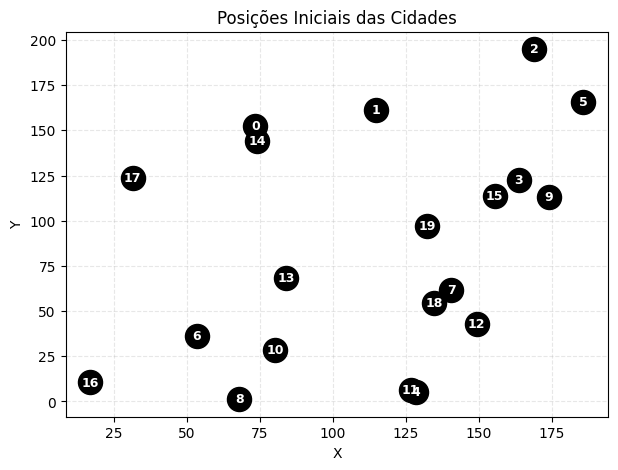

In [22]:
plotar_cidades(coordenadas)

### 3.5.3 Resultado Final

In [23]:
aco = TSPACO(
    custos=distancias,
    n_formigas=N_FORMIGAS,
    alfa=ALFA,
    beta=BETA,
    n_iteracoes=N_ITERACOES,
    taxa_evaporacao=TAXA_EVAPORACAO,
)

In [24]:
melhor_rota, melhor_custo = aco.otimizar(VERTICE_INICIAL)

print("Melhor rota encontrada:", melhor_rota)
print("Custo da melhor rota encontrada:", melhor_custo)

Melhor rota encontrada: [0, 14, 17, 13, 10, 6, 16, 8, 11, 4, 12, 18, 7, 19, 15, 3, 9, 5, 2, 1, 0]
Custo da melhor rota encontrada: 712.0308935712125


In [25]:
metricas = aco.obter_metricas()
metricas

,iteracao,melhor_custo,pior_custo,custo_medio,custo_desvio,tempo_ms
0,0,975.49,1395.25,1126.37,104.62,2.37
1,1,888.34,1289.48,1099.20,99.63,2.14
2,2,810.34,1302.81,1038.06,109.77,2.11
3,3,745.89,1162.11,990.33,99.74,2.96
4,4,767.02,1169.74,942.13,102.19,3.72
5,5,734.20,1125.41,959.66,99.39,2.66
6,6,721.63,1066.74,916.22,98.61,2.69
7,7,734.20,1022.10,890.73,93.92,1.94
8,8,712.03,1079.44,872.18,111.97,2.03
9,9,712.03,989.28,850.01,96.32,2.02


In [26]:
ani = animar_aco(aco, coordenadas)
HTML(ani.to_html5_video())

RuntimeError: Requested MovieWriter (ffmpeg) not available

## 3.6 Vantagens e Desvantagens

### 3.6.1 Vantagens

- **Paralelização Natural:** como as formigas funcionam como agentes independentes, o algoritmo pode ser facilmente paralelizado em múltiplos processadores ou em sistemas distribuídos.

- **Exploração vs. Intesificação:** o mecanismo de reforço do feromônio (exploração) e da evaporação (diversificação) cria um equilíbrio natural entre intensificação (explorar soluções boas já conhecidas) e diversificação (buscar novas soluções).

- **Flexibilidade de Aplicação:** pode ser adaptado para uma variedade de problemas (logística, telecomunicações, engenharia, bioinformática etc).

### 3.6.2 Desvantagens

- **Risco de Convergência Prematura:** se algumas soluções são reforçadas cedo demais, o algoritmo pode ficar preso em ótimos locais, pois o excesso de feromônio num caminho pode desestimular a exploração de alternativas.

- **Alto Custo Computacional:** a manutenção da matriz de feromônio e a simulação de muitas formigas podem ser computacionalmente custosas, especialmente em problemas com espaço de busca muito grande.

- **Sensibilidade a Parâmetros:** o desempenho depende fortemente de parâmetros como: taxa de evaporação do feromônio, peso entre feromônio e heurística, número de formigas. Pequenas mudanças podem alterar muito a qualidade da solução.